# Postprocessing: Diagnostics

Loads summary CSV and inspects artifacts for a single run (nuisance fit diagnostics).


In [1]:
import os
from pathlib import Path

cwd = Path.cwd()
if cwd.name == "notebooks":
    os.chdir(cwd.parent)

In [2]:

import csv
import os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def load_summary(path):
    rows = []
    with open(path, newline='', encoding='utf-8-sig') as f:
        reader = csv.DictReader(f)
        for row in reader:
            rows.append(row)
    return rows

def as_float(x):
    try:
        return float(x)
    except Exception:
        return float('nan')

def summarize_rows(rows, n=5):
    print(f'Total rows: {len(rows)}')
    for r in rows[:n]:
        print({k: r.get(k) for k in ['run_id','method','dgp','rep','run_seed','status','artifacts_dir']})

def filter_rows_with_artifacts(rows):
    return [r for r in rows if r.get('artifacts_dir')]


def normalize_artifacts_dir(artifacts_dir):
    p = Path(artifacts_dir)
    if p.exists():
        return str(p)
    s = str(p).replace('\\', '/')
    linux_root = '/home/javureke/projects/Generalized-Bayes-for-CI'
    if s.startswith(linux_root):
        candidate = Path(s.replace(linux_root, str(Path.cwd())))
        if candidate.exists():
            return str(candidate)
    marker = '/results/'
    if marker in s:
        suffix = s.split(marker, 1)[1]
        candidate = Path.cwd() / 'results' / suffix
        if candidate.exists():
            return str(candidate)
    return str(p)

def load_artifacts(artifacts_dir):
    artifacts_dir = normalize_artifacts_dir(artifacts_dir)
    arrays_path = os.path.join(artifacts_dir, 'arrays.npz')
    run_cfg_path = os.path.join(artifacts_dir, 'run_config.json')
    history_path = os.path.join(artifacts_dir, 'history.json')
    arrays = dict(np.load(arrays_path)) if os.path.exists(arrays_path) else {}
    run_cfg = None
    history = None
    if os.path.exists(run_cfg_path):
        import json
        with open(run_cfg_path, 'r', encoding='utf-8-sig') as f:
            run_cfg = json.load(f)
    if os.path.exists(history_path):
        import json
        with open(history_path, 'r', encoding='utf-8-sig') as f:
            history = json.load(f)
    return arrays, run_cfg, history

def r2_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1.0 - ss_res / ss_tot



def nuisance_diagnostics_iv(pi_hat, m_y0_hat, m_y1_hat, m_a0_hat, m_a1_hat, Y, A, Z):
    z1 = (Z == 1)
    z0 = (Z == 0)
    mse_z0 = np.mean((Y[z0] - m_y0_hat[z0]) ** 2) if np.any(z0) else np.nan
    mse_z1 = np.mean((Y[z1] - m_y1_hat[z1]) ** 2) if np.any(z1) else np.nan
    r2_z0 = r2_score(Y[z0], m_y0_hat[z0]) if np.any(z0) else np.nan
    r2_z1 = r2_score(Y[z1], m_y1_hat[z1]) if np.any(z1) else np.nan
    overlap = np.mean((pi_hat > 0.05) & (pi_hat < 0.95))
    first_stage = np.mean(m_a1_hat - m_a0_hat)
    print(f'MSE(m_y|Z=0): {mse_z0:.3f}, MSE(m_y|Z=1): {mse_z1:.3f}')
    print(f'R2(m_y|Z=0): {r2_z0:.3f}, R2(m_y|Z=1): {r2_z1:.3f}')
    print(f'Instrument mean: {pi_hat.mean():.3f}, std: {pi_hat.std():.3f}, overlap: {overlap:.3f}')
    print(f'First stage mean (m_a1 - m_a0): {first_stage:.3f}')

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    bins = np.linspace(0, 1, 25)
    axs[0, 0].hist(pi_hat[z0], bins=bins, alpha=0.6, label='Z=0')
    axs[0, 0].hist(pi_hat[z1], bins=bins, alpha=0.6, label='Z=1')
    axs[0, 0].set_title('Instrument propensity histograms')
    axs[0, 0].set_xlabel('pi_hat')
    axs[0, 0].legend()

    axs[0, 1].scatter(m_y0_hat[z0], Y[z0], s=8, alpha=0.5, color='C0')
    lo, hi = np.percentile(Y, [1, 99])
    axs[0, 1].plot([lo, hi], [lo, hi], 'k--', lw=1)
    axs[0, 1].set_title('m_y0_hat vs. Y (Z=0)')
    axs[0, 1].set_xlabel('m_y0_hat')
    axs[0, 1].set_ylabel('Y')

    axs[1, 1].scatter(m_y1_hat[z1], Y[z1], s=8, alpha=0.5, color='C1')
    axs[1, 1].plot([lo, hi], [lo, hi], 'k--', lw=1)
    axs[1, 1].set_title('m_y1_hat vs. Y (Z=1)')
    axs[1, 1].set_xlabel('m_y1_hat')
    axs[1, 1].set_ylabel('Y')

    res0 = Y[z0] - m_y0_hat[z0]
    res1 = Y[z1] - m_y1_hat[z1]
    axs[1, 0].scatter(m_y0_hat[z0], res0, s=8, alpha=0.5, color='C0', label='Z=0')
    axs[1, 0].scatter(m_y1_hat[z1], res1, s=8, alpha=0.5, color='C1', label='Z=1')
    axs[1, 0].axhline(0.0, color='k', linestyle='--', lw=1)
    axs[1, 0].set_title('Residuals vs fitted (by Z)')
    axs[1, 0].set_xlabel('m_y_hat')
    axs[1, 0].set_ylabel('Y - m_y_hat')
    axs[1, 0].legend()

    plt.tight_layout()
    plt.show()

def gbi_diagnostics(history):
    if not history:
        print('No history found (track_grads was False).')
        return
    steps = [h.get('step') for h in history]
    objective = [h.get('objective') for h in history]
    grad_mu = [abs(h.get('grad_mu', 0.0)) for h in history]
    grad_log_sigma = [abs(h.get('grad_log_sigma', 0.0)) for h in history]
    delta_mu = [h.get('delta_mu', 0.0) for h in history]
    delta_log_sigma = [h.get('delta_log_sigma', 0.0) for h in history]
    data_term = [h.get('data_term') for h in history]
    kl_term = [h.get('kl_term') for h in history]

    fig, axs = plt.subplots(2, 2, figsize=(12, 8))

    # Objective curve: should generally decrease or stabilize.
    axs[0, 0].plot(steps, objective)
    axs[0, 0].set_title('GBI objective')
    axs[0, 0].set_xlabel('Step')
    axs[0, 0].set_ylabel('Objective')
    axs[0, 0].set_yscale('log')

    # Gradient magnitudes: should decay as optimization stabilizes.
    axs[0, 1].plot(steps, grad_mu, label='|grad_mu|')
    axs[0, 1].plot(steps, grad_log_sigma, label='|grad_log_sigma|')
    axs[0, 1].set_title('GBI gradient magnitudes')
    axs[0, 1].set_xlabel('Step')
    axs[0, 1].set_ylabel('Magnitude')
    axs[0, 1].set_yscale('log')
    axs[0, 1].legend()

    # Parameter update sizes.
    axs[1, 0].plot(steps, delta_mu, label='delta_mu')
    axs[1, 0].plot(steps, delta_log_sigma, label='delta_log_sigma')
    axs[1, 0].set_title('GBI parameter updates')
    axs[1, 0].set_xlabel('Step')
    axs[1, 0].set_ylabel('Update')
    axs[1, 0].legend()

    # Objective components.
    axs[1, 1].plot(steps, data_term, label='data_term')
    axs[1, 1].plot(steps, kl_term, label='kl_term')
    axs[1, 1].plot(steps, objective, label='objective')
    axs[1, 1].set_title('GBI objective components')
    axs[1, 1].set_xlabel('Step')
    axs[1, 1].set_ylabel('Value')
    axs[1, 1].set_yscale('log')
    axs[1, 1].legend()

    plt.tight_layout()
    plt.show()


In [3]:

# experiment_id = 'exp1_backdoor_ate_TEST_(1)'  # change as needed
# experiment_id = 'exp1_iv_ate_attempt_1'
experiment_id = 'exp1_iv_ate_attempt_1_TEST'

results_root = 'results'
summary_path = os.path.join(results_root, experiment_id, 'summary.csv')

rows = load_summary(summary_path)
summarize_rows(rows)

rows_with_artifacts = filter_rows_with_artifacts(rows)
print(f'Rows with artifacts: {len(rows_with_artifacts)}')


summarize_rows(rows_with_artifacts, n=10)


Total rows: 30
{'run_id': 'run_23f119387821', 'method': 'wald_iv', 'dgp': 'dgp_iv_0', 'rep': '0', 'run_seed': '2447688045', 'status': 'ok', 'artifacts_dir': 'C:\\Users\\javurek\\Desktop\\Generalised Bayes\\results\\exp1_iv_ate_attempt_1_TEST\\artifacts\\run_23f119387821'}
{'run_id': 'run_0175c7328768', 'method': 'wald_iv', 'dgp': 'dgp_iv_0', 'rep': '1', 'run_seed': '268361167', 'status': 'ok', 'artifacts_dir': ''}
{'run_id': 'run_2282b7c1fe6a', 'method': 'wald_iv', 'dgp': 'dgp_iv_0', 'rep': '2', 'run_seed': '3195700252', 'status': 'ok', 'artifacts_dir': ''}
{'run_id': 'run_1700d8d6c2ae', 'method': 'wald_iv', 'dgp': 'dgp_iv_0', 'rep': '3', 'run_seed': '1038075435', 'status': 'ok', 'artifacts_dir': ''}
{'run_id': 'run_1fc0e0673412', 'method': 'wald_iv', 'dgp': 'dgp_iv_0', 'rep': '4', 'run_seed': '3313567789', 'status': 'ok', 'artifacts_dir': ''}
Rows with artifacts: 6
Total rows: 6
{'run_id': 'run_23f119387821', 'method': 'wald_iv', 'dgp': 'dgp_iv_0', 'rep': '0', 'run_seed': '2447688045'

In [4]:

# Choose a run_id from the summary to inspect (prefer one with artifacts_dir)
row_n = 1
run_id = rows_with_artifacts[row_n]['run_id']
artifacts_dir = rows_with_artifacts[row_n]['artifacts_dir']

arrays, run_cfg, history = load_artifacts(artifacts_dir)

m_a0_hat = arrays.get('m_a0_hat')
m_a1_hat = arrays.get('m_a1_hat')

# Pull arrays
if not arrays:
    raise FileNotFoundError(f'No arrays.npz found in {artifacts_dir}')

pi_hat = arrays.get('pi_hat')
m_y0_hat = arrays.get('m_y0_hat')
m_y1_hat = arrays.get('m_y1_hat')

# Load data from run_config + re-simulate for diagnostics (same seed + dgp)
print('Run config:', run_cfg['data'] if run_cfg else None)


Run config: {'data_kind': 'iv', 'dgp_fn_REGISTRATION': 'dgp_iv_0', 'dgp_kwargs': {}, 'n': 10000}


MSE(m_y|Z=0): 0.993, MSE(m_y|Z=1): 0.111
R2(m_y|Z=0): 0.671, R2(m_y|Z=1): 0.946
Instrument mean: 0.494, std: 0.029, overlap: 1.000
First stage mean (m_a1 - m_a0): 0.470


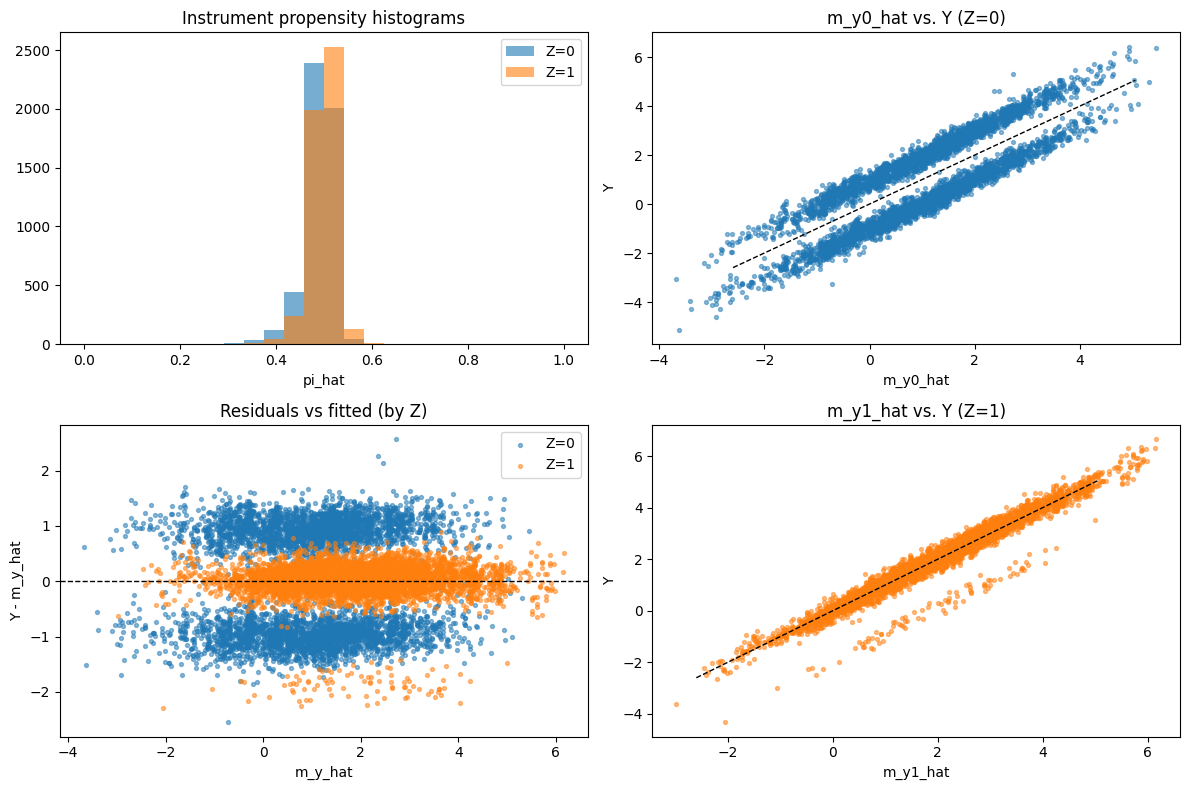

In [5]:
# Re-simulate data using src.py to get X, A, Y for plotting
import importlib.util
import pathlib

src_path = pathlib.Path('src.py').resolve()
spec = importlib.util.spec_from_file_location('src', src_path)
src = importlib.util.module_from_spec(spec)
spec.loader.exec_module(src)

dgp_name = run_cfg['data']['dgp_fn_REGISTRATION']
data_cfg = run_cfg.get('data', {})
misc_cfg = run_cfg.get('misc', {})
run_seed = misc_cfg.get('run_seed')
run_seed = int(run_seed) if run_seed is not None else None
if run_seed is not None:
    seed = src.build_run_seeds(run_seed)["dgp"]
else:
    seed = data_cfg.get('seed', None)
    seed = int(seed) if seed is not None else None
n = int(data_cfg['n'])
dgp_kwargs = data_cfg.get('dgp_kwargs', {})

dgp_fn = src._resolve_from_registry(dgp_name, src._DGP_IV_REGISTRY, 'dgp_fn_REGISTRATION')
if seed is None:
    data = dgp_fn(n=n, **dgp_kwargs)
else:
    data = dgp_fn(n=n, seed=seed, **dgp_kwargs)
A = data['A']
Y = data['Y']
Z = data['Z']
X = data['X']  # used later

nuisance_diagnostics_iv(pi_hat, m_y0_hat, m_y1_hat, m_a0_hat, m_a1_hat, Y, A, Z)


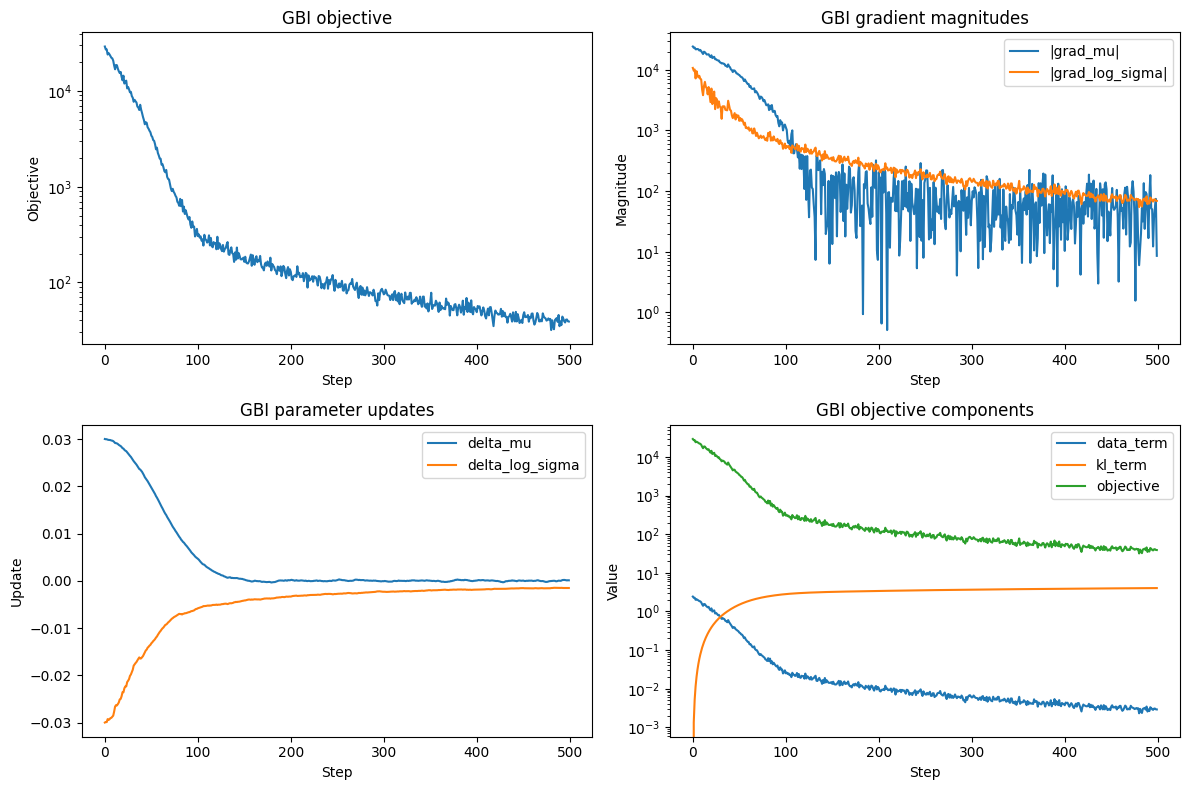

In [6]:
# GBI optimization diagnostics
gbi_diagnostics(history)


In [7]:
# IV diagnostics: overlap and first-stage strength
import numpy as np

def summarize_overlap(arr, name, lo=0.05, hi=0.95):
    arr = np.asarray(arr)
    inside = np.mean((arr > lo) & (arr < hi))
    print(f'{name}: mean={arr.mean():.3f}, std={arr.std():.3f}, overlap={inside:.3f}')

summarize_overlap(pi_hat, 'pi_hat')

delta_a = m_a1_hat - m_a0_hat
print(f'delta_a: mean={delta_a.mean():.4f}, std={delta_a.std():.4f}, min={delta_a.min():.4f}, max={delta_a.max():.4f}')
print(f'delta_a |<0.02| fraction: {np.mean(np.abs(delta_a) < 0.02):.3f}')
print(f'Z balance: P(Z=1)={np.mean(Z==1):.3f}, P(Z=0)={np.mean(Z==0):.3f}')
print(f'First-stage (A|Z): P(A=1|Z=1)={np.mean(A[Z==1]):.3f}, P(A=1|Z=0)={np.mean(A[Z==0]):.3f}')


pi_hat: mean=0.494, std=0.029, overlap=1.000
delta_a: mean=0.4705, std=0.0471, min=0.2918, max=0.6569
delta_a |<0.02| fraction: 0.000
Z balance: P(Z=1)=0.494, P(Z=0)=0.506
First-stage (A|Z): P(A=1|Z=1)=0.982, P(A=1|Z=0)=0.502


In [8]:
# Recompute DR-IV phi with different delta_a clipping to diagnose instability
def _clip_with_sign(x, min_abs):
    sign = np.sign(x)
    sign[sign == 0] = 1.0
    return sign * np.maximum(np.abs(x), min_abs)


def dr_iv_phi_from_nuisances(X, Z, A, Y, pi_hat, m_y0_hat, m_y1_hat, m_a0_hat, m_a1_hat, clip_eps=1e-3, clip_delta_a=1e-2):
    pi = np.clip(pi_hat, clip_eps, 1 - clip_eps)
    delta_y = m_y1_hat - m_y0_hat
    delta_a = m_a1_hat - m_a0_hat
    delta_a = _clip_with_sign(delta_a, clip_delta_a)
    m_yz = np.where(Z == 1, m_y1_hat, m_y0_hat)
    m_az = np.where(Z == 1, m_a1_hat, m_a0_hat)
    h = (Z - pi) / (pi * (1 - pi))
    phi = (delta_y / delta_a) + (h / delta_a) * (Y - m_yz) - (delta_y * h / (delta_a ** 2)) * (A - m_az)
    return phi

for clip in [1e-3, 5e-3, 1e-2, 5e-2]:
    phi = dr_iv_phi_from_nuisances(X, Z, A, Y, pi_hat, m_y0_hat, m_y1_hat, m_a0_hat, m_a1_hat, clip_delta_a=clip)
    print(f'clip_delta_a={clip:.3g}: mean={phi.mean():.4f}, std={phi.std():.4f}, min={phi.min():.3f}, max={phi.max():.3f}')


clip_delta_a=0.001: mean=1.9748, std=1.0219, min=-6.618, max=8.272
clip_delta_a=0.005: mean=1.9748, std=1.0219, min=-6.618, max=8.272
clip_delta_a=0.01: mean=1.9748, std=1.0219, min=-6.618, max=8.272
clip_delta_a=0.05: mean=1.9748, std=1.0219, min=-6.618, max=8.272


wald: mean=1.9890, std=0.2540 | winsor mean=1.9885, std=0.2475
dr: mean=1.9748, std=1.0219 | winsor mean=1.9762, std=0.9845


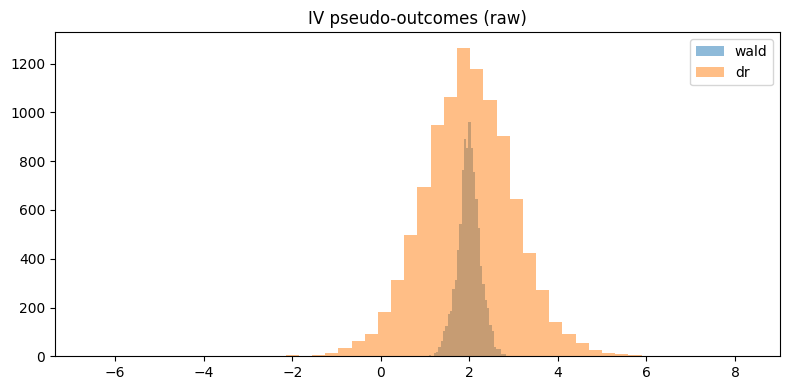

In [9]:
# Compare Wald vs DR-IV with simple winsorization
def _clip_with_sign(x, min_abs):
    sign = np.sign(x)
    sign[sign == 0] = 1.0
    return sign * np.maximum(np.abs(x), min_abs)


def wald_iv_phi_from_nuisances(m_y0_hat, m_y1_hat, m_a0_hat, m_a1_hat, clip_delta_a=1e-2):
    delta_y = m_y1_hat - m_y0_hat
    delta_a = m_a1_hat - m_a0_hat
    delta_a = _clip_with_sign(delta_a, clip_delta_a)
    return delta_y / delta_a

def winsorize(x, q=0.01):
    lo, hi = np.quantile(x, [q, 1 - q])
    return np.clip(x, lo, hi)

phi_wald = wald_iv_phi_from_nuisances(m_y0_hat, m_y1_hat, m_a0_hat, m_a1_hat, clip_delta_a=1e-2)
phi_dr = dr_iv_phi_from_nuisances(X, Z, A, Y, pi_hat, m_y0_hat, m_y1_hat, m_a0_hat, m_a1_hat, clip_delta_a=1e-2)

for name, phi in [('wald', phi_wald), ('dr', phi_dr)]:
    phi_w = winsorize(phi, q=0.01)
    print(f'{name}: mean={phi.mean():.4f}, std={phi.std():.4f} | winsor mean={phi_w.mean():.4f}, std={phi_w.std():.4f}')

# Optional quick histogram
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(phi_wald, bins=50, alpha=0.5, label='wald')
plt.hist(phi_dr, bins=50, alpha=0.5, label='dr')
plt.title('IV pseudo-outcomes (raw)')
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# First-stage diagnostics by X1 bins
x1 = X[:, 0]
bins = np.quantile(x1, np.linspace(0, 1, 6))
print('X1 bins:', bins)
for i in range(len(bins)-1):
    mask = (x1 >= bins[i]) & (x1 <= bins[i+1])
    if mask.sum() == 0:
        continue
    pz1 = np.mean(Z[mask])
    pa1_z1 = np.mean(A[mask & (Z==1)]) if np.any(mask & (Z==1)) else np.nan
    pa1_z0 = np.mean(A[mask & (Z==0)]) if np.any(mask & (Z==0)) else np.nan
    print(f'bin {i}: P(Z=1)={pz1:.3f}, P(A=1|Z=1)={pa1_z1:.3f}, P(A=1|Z=0)={pa1_z0:.3f}')


X1 bins: [-3.51513443 -0.8282827  -0.24965167  0.25448647  0.84045826  3.92814816]
bin 0: P(Z=1)=0.488, P(A=1|Z=1)=0.986, P(A=1|Z=0)=0.488
bin 1: P(Z=1)=0.497, P(A=1|Z=1)=0.979, P(A=1|Z=0)=0.486
bin 2: P(Z=1)=0.494, P(A=1|Z=1)=0.983, P(A=1|Z=0)=0.515
bin 3: P(Z=1)=0.503, P(A=1|Z=1)=0.980, P(A=1|Z=0)=0.522
bin 4: P(Z=1)=0.489, P(A=1|Z=1)=0.982, P(A=1|Z=0)=0.501


term_wald: mean=1.9890, std=0.2540, min=0.724, max=3.341, q=[1.204,1.375,1.989,2.585,2.880]
term_y: mean=0.0080, std=3.1803, min=-14.407, max=10.344, q=[-9.878,-6.835,0.173,6.483,7.944]
term_a: mean=-0.0222, std=3.1123, min=-9.601, max=12.992, q=[-8.203,-6.182,-0.175,6.046,9.839]
phi_dr: mean=1.9748, std=1.0219, min=-6.618, max=8.272, q=[-2.038,-0.510,1.972,4.430,5.436]
h: mean=-0.0009, std=1.9887, min=-2.475, max=3.008, q=[-2.290,-2.141,-1.622,2.325,2.605]
delta_a_clip: mean=0.4705, std=0.0471, min=0.292, max=0.657, q=[0.314,0.354,0.468,0.596,0.640]
mean |term|: 1.9890132664279845 2.494787088765272 2.25965604452625
corr(phi, term_wald): 0.03647920329720578
corr(phi, term_y): 0.22133621154373
corr(phi, term_a): 0.0991966232226107


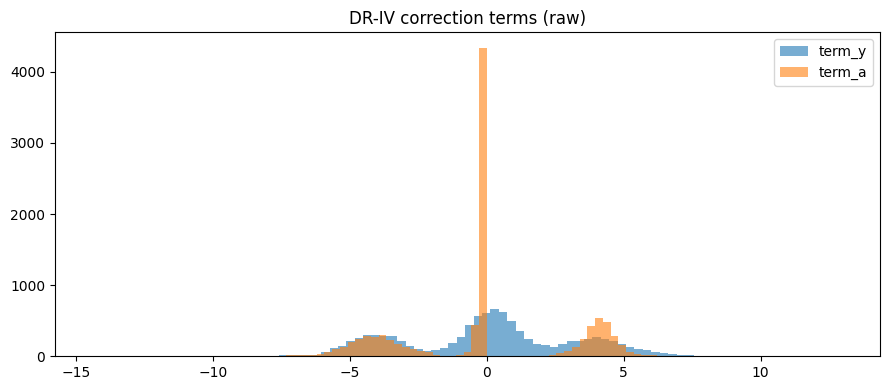

In [11]:
# Decompose DR-IV phi into components to see which term explodes
def _clip_with_sign(x, min_abs):
    sign = np.sign(x)
    sign[sign == 0] = 1.0
    return sign * np.maximum(np.abs(x), min_abs)


def dr_iv_components(X, Z, A, Y, pi_hat, m_y0_hat, m_y1_hat, m_a0_hat, m_a1_hat, clip_eps=1e-2, clip_delta_a=5e-2):
    pi = np.clip(pi_hat, clip_eps, 1 - clip_eps)
    delta_y = m_y1_hat - m_y0_hat
    delta_a = m_a1_hat - m_a0_hat
    delta_a = _clip_with_sign(delta_a, clip_delta_a)
    m_yz = np.where(Z == 1, m_y1_hat, m_y0_hat)
    m_az = np.where(Z == 1, m_a1_hat, m_a0_hat)
    h = np.where(Z == 0, -1 / (1 - pi), 1 / pi)
    term_wald = delta_y / delta_a
    term_y = (h / delta_a) * (Y - m_yz)
    term_a = -(delta_y * h / (delta_a ** 2)) * (A - m_az)
    phi = term_wald + term_y + term_a
    return term_wald, term_y, term_a, phi, h, delta_a

def stats(name, arr):
    arr = np.asarray(arr)
    qs = np.quantile(arr, [0.001, 0.01, 0.5, 0.99, 0.999])
    print(f'{name}: mean={arr.mean():.4f}, std={arr.std():.4f}, min={arr.min():.3f}, max={arr.max():.3f}, q=[{qs[0]:.3f},{qs[1]:.3f},{qs[2]:.3f},{qs[3]:.3f},{qs[4]:.3f}]')

term_wald, term_y, term_a, phi_dr, h, delta_a_clip = dr_iv_components(
    X, Z, A, Y, pi_hat, m_y0_hat, m_y1_hat, m_a0_hat, m_a1_hat, clip_eps=1e-2, clip_delta_a=5e-2
)
stats('term_wald', term_wald)
stats('term_y', term_y)
stats('term_a', term_a)
stats('phi_dr', phi_dr)
stats('h', h)
stats('delta_a_clip', delta_a_clip)

# Contribution magnitudes
print('mean |term|:', np.mean(np.abs(term_wald)), np.mean(np.abs(term_y)), np.mean(np.abs(term_a)))
print('corr(phi, term_wald):', np.corrcoef(phi_dr, term_wald)[0,1])
print('corr(phi, term_y):', np.corrcoef(phi_dr, term_y)[0,1])
print('corr(phi, term_a):', np.corrcoef(phi_dr, term_a)[0,1])

# Optional hist to see tail source
import matplotlib.pyplot as plt
plt.figure(figsize=(9,4))
plt.hist(term_y, bins=80, alpha=0.6, label='term_y')
plt.hist(term_a, bins=80, alpha=0.6, label='term_a')
plt.title('DR-IV correction terms (raw)')
plt.legend()
plt.tight_layout()
plt.show()
